In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CSV_PATH = "landmarks_unnormalised_with_angles_clean.csv"  # change path if needed
df = pd.read_csv(CSV_PATH)
positions_order = sorted(df["Position"].unique(), key=lambda x: int(x[1:]))  # extracts the number part
df["Position"] = pd.Categorical(df["Position"], categories=positions_order, ordered=True)
df = df.sort_values("Position")

# df = df[df["Person"].str.contains("rob", na=False)]

# --- Clean / sanity check ---
print("Loaded data:", df.shape)
display(df.head())

summary = df.groupby("Position")[["shoulder_tilt_deg", "hip_tilt_deg",
                                  "shoulder_rotation_deg", "hip_rotation_deg"]].agg(
    ["mean", "std", "min", "max"]
)
summary

Loaded data: (379, 10)


,Unnamed: 0,Frame_Name,Person,Camera_Angle,Frame_Number,Position,shoulder_tilt_deg,hip_tilt_deg,shoulder_rotation_deg,hip_rotation_deg
0,0,eric_DTL_1_frame0.jpg,eric_DTL_1,FO,frame0,P1,15.339738,3.616193,87.832446,83.582806
28,28,rob_DTL_2_frame20.jpg,rob_DTL_2,FO,frame20,P1,82.899608,26.643919,89.521035,87.609570
29,29,tom_DTL_1_frame20.jpg,tom_DTL_1,FO,frame20,P1,3.180439,1.587600,83.021747,79.570944
30,30,tom_DTL_1_frame21.jpg,tom_DTL_1,FO,frame21,P1,0.750091,0.958333,82.926085,79.928105
31,31,rob_DTL_2_frame22.jpg,rob_DTL_2,FO,frame22,P1,77.829540,76.965297,88.843763,88.928176


C:\Users\cryst\AppData\Local\Temp\ipykernel_4512\2057038772.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("Position")[["shoulder_tilt_deg", "hip_tilt_deg",


shoulder_tilt_deg                                 hip_tilt_deg  \
                      mean        std       min        max         mean   
Position                                                                  
P1               33.633530  25.865862  0.393149  85.684687    23.211982   
P2               34.941795  23.367361  1.435576  89.817817    23.128776   
P3               32.809815  15.284176  0.226389  74.186263    25.144310   
P4               33.929350  18.731366  0.182533  77.145744    29.295106   
P5               43.736087  22.714835  1.368515  88.447650    34.343758   
P6               41.220409  20.695368  8.320940  68.698520    15.463901   
P7               44.294540  20.301696  0.747557  79.943191    42.819800   
P8               51.042921  21.834716  4.419102  89.541567    42.968177   
P9               36.573467  13.274920  1.330273  67.527560    28.541918   
P10              31.084811  19.360614  3.825733  84.669846    22.620049   

                                         shoulder_rotation_deg             \
                std       min        max                  mean        std   
Position                                                                    
P1        25.627398  0.078086  88.299797             81.335171  16.917085   
P2        22.801313  0.072608  84.158912             78.759095  12.483984   
P3        21.527710  1.299684  82.754767             66.084723  18.025875   
P4        23.289310  1.648659  81.824989             48.354494  30.199842   
P5        29.123811  3.265166  89.478913             77.645083  15.227230   
P6        15.691466  1.791057  49.259317             84.867732   4.809892   
P7        24.083881  0.869060  79.264158             84.659323   5.331438   
P8        27.365548  3.062185  84.102944             74.192985  16.777652   
P9        20.142834  0.835036  72.621748             66.360872  18.378489   
P10       20.130753  0.526433  80.337727             47.238303  25.783339   

                               hip_rotation_deg                        \
                min        max             mean        std        min   
Position                                                                
P1         4.722744  89.521035        81.560817   9.640024  24.596407   
P2         1.700325  89.996474        79.074276  10.601681  15.041442   
P3         2.789961  89.191944        73.027530  16.213535   7.150242   
P4         1.622811  88.852128        72.762612  18.521212   7.720581   
P5        23.585183  89.901754        81.904764   8.135480  45.662028   
P6        69.782463  88.853308        85.252226   3.217620  76.148350   
P7        64.947485  89.692306        85.481385   5.271663  61.234256   
P8        11.037621  89.707021        80.250183  11.207345  34.122323   
P9         6.696620  83.489647        74.553498  14.357224  15.289944   
P10        2.656685  88.382372        58.874834  20.215769  12.178157   

                     
                max  
Position             
P1        89.939000  
P2        89.759836  
P3        89.074677  
P4        89.398933  
P5        89.988411  
P6        89.354047  
P7        89.713639  
P8        89.826182  
P9        88.038372  
P10       89.703911

In [3]:
# --- Load both datasets ---
df_coach = pd.read_csv("standard_angles.csv")

# --- Merge by Position (not Frame_Name) ---
df_compare = pd.merge(df, df_coach, on="Position", how="left")

# --- Compute differences per frame (Mediapipe - Coach) ---
for angle in ["shoulder_tilt_deg", "hip_tilt_deg", "shoulder_rotation_deg", "hip_rotation_deg"]:
    df_compare[f"{angle}_diff"] = df_compare[angle] - df_compare[f"{angle.replace("_deg", "_standard")}"]
    df_compare[f"{angle}_abs_diff"] = df_compare[f"{angle}_diff"].abs()

# --- Summary: Mean absolute difference per position ---
summary_diff = df_compare.groupby("Position")[[
    "shoulder_tilt_deg_abs_diff",
    "hip_tilt_deg_abs_diff",
    "shoulder_rotation_deg_abs_diff",
    "hip_rotation_deg_abs_diff"
]].mean().reset_index()

display(summary_diff)

,Position,shoulder_tilt_deg_abs_diff,hip_tilt_deg_abs_diff,shoulder_rotation_deg_abs_diff,hip_rotation_deg_abs_diff
0,P1,27.933253,22.319007,73.461219,77.560817
1,P10,25.188347,18.052068,90.761697,50.125166
2,P2,18.340557,19.536476,38.438248,61.197549
3,P3,11.645509,18.320376,13.428492,39.389994
4,P4,14.807956,21.715379,39.693789,32.732051
5,P5,19.492481,27.796203,18.001989,74.904764
6,P6,29.629193,11.163798,83.867732,53.252226
7,P7,20.165754,32.884890,53.659323,42.481385
8,P8,18.944898,32.093830,26.399731,28.760398
9,P9,12.158655,16.479843,11.735013,16.146956


In [4]:
# Flatten MultiIndex columns (mean/std/min/max)
summary.columns = ['_'.join(col).strip('_') for col in summary.columns.to_flat_index()]
summary = summary.reset_index()

# Merge with coach standard angles
df_compare_summary = pd.merge(summary, df_coach, on="Position", how="left")

display(df_compare_summary.head())

,Position,shoulder_tilt_deg_mean,shoulder_tilt_deg_std,shoulder_tilt_deg_min,shoulder_tilt_deg_max,hip_tilt_deg_mean,hip_tilt_deg_std,hip_tilt_deg_min,hip_tilt_deg_max,shoulder_rotation_deg_mean,...,hip_rotation_deg_std,hip_rotation_deg_min,hip_rotation_deg_max,shoulder_tilt_standard,hip_tilt_standard,LR,shoulder_rotation_standard,hip_rotation_standard,OC,tilt_ca
0,P1,33.633530,25.865862,0.393149,85.684687,23.211982,25.627398,0.078086,88.299797,81.335171,...,9.640024,24.596407,89.939000,8,1,R,8,4,O,FO
1,P2,34.941795,23.367361,1.435576,89.817817,23.128776,22.801313,0.072608,84.158912,78.759095,...,10.601681,15.041442,89.759836,24,4,L,42,18,C,FO
2,P3,32.809815,15.284176,0.226389,74.186263,25.144310,21.527710,1.299684,82.754767,66.084723,...,16.213535,7.150242,89.074677,35,8,L,77,36,C,DTL
3,P4,33.929350,18.731366,0.182533,77.145744,29.295106,23.289310,1.648659,81.824989,48.354494,...,18.521212,7.720581,89.398933,37,9,L,88,44,C,DTL
4,P5,43.736087,22.714835,1.368515,88.447650,34.343758,29.123811,3.265166,89.478913,77.645083,...,8.135480,45.662028,89.988411,33,7,L,65,7,C,DTL


C:\Users\cryst\AppData\Local\Temp\ipykernel_4512\1593665105.py:7: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


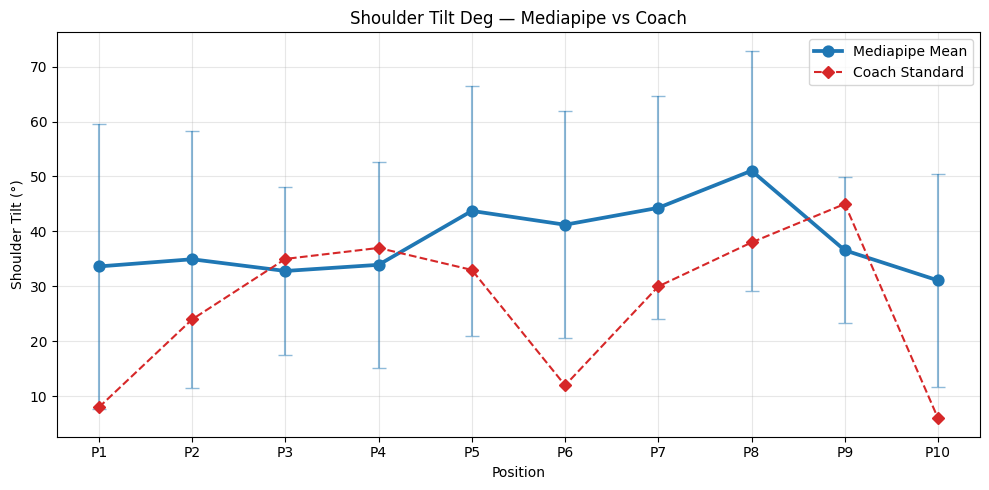

C:\Users\cryst\AppData\Local\Temp\ipykernel_4512\1593665105.py:7: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


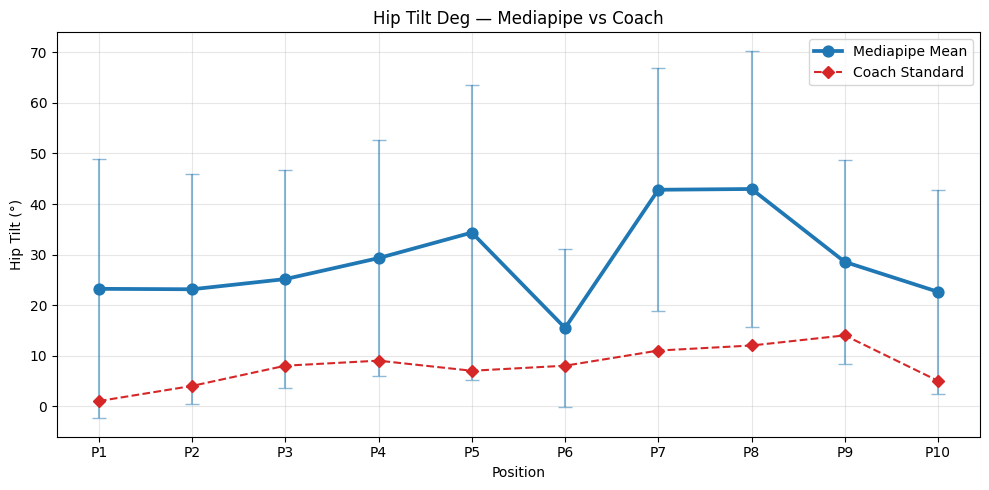

C:\Users\cryst\AppData\Local\Temp\ipykernel_4512\1593665105.py:7: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


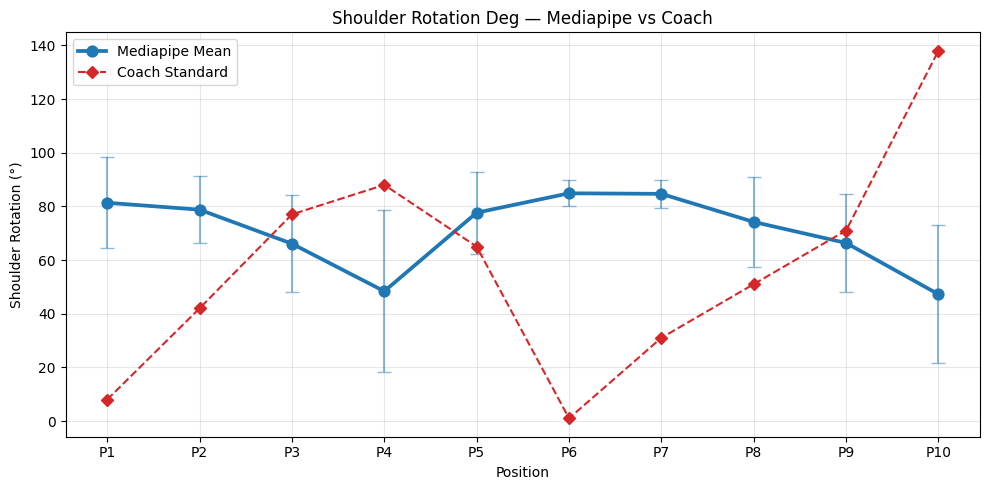

C:\Users\cryst\AppData\Local\Temp\ipykernel_4512\1593665105.py:7: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


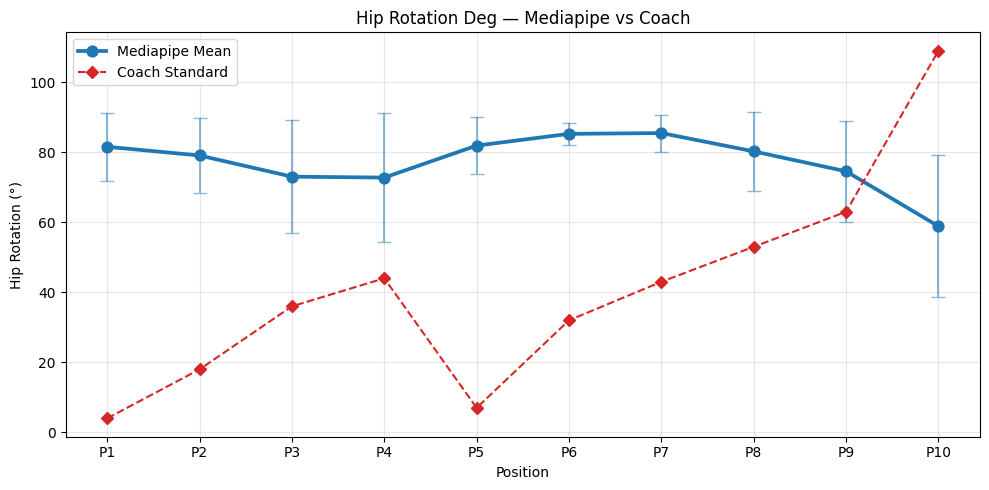

In [5]:
def plot_angle_comparison(angle_name, ylabel=None):
    mean_col = f"{angle_name}_mean"
    std_col = f"{angle_name}_std"
    coach_col = f"{angle_name.replace('_deg', '_standard')}"  # e.g. shoulder_tilt_standard

    plt.figure(figsize=(10, 5))
    sns.pointplot(
        data=df_compare_summary,
        x="Position",
        y=mean_col,
        color="tab:blue",
        markers="o",
        label="Mediapipe Mean",
        join=True
    )

    # Add ± std range as error bars
    plt.errorbar(
        x=range(len(df_compare_summary)),
        y=df_compare_summary[mean_col],
        yerr=df_compare_summary[std_col],
        fmt="none",
        ecolor="tab:blue",
        alpha=0.5,
        capsize=5
    )

    # Add coach’s standard as red dashed line
    plt.plot(df_compare_summary["Position"], df_compare_summary[coach_col],
             color="tab:red", marker="D", linestyle="--", label="Coach Standard")

    plt.title(f"{angle_name.replace('_', ' ').title()} — Mediapipe vs Coach")
    plt.xlabel("Position")
    plt.ylabel(ylabel or "Angle (°)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_angle_comparison("shoulder_tilt_deg", "Shoulder Tilt (°)")
plot_angle_comparison("hip_tilt_deg", "Hip Tilt (°)")
plot_angle_comparison("shoulder_rotation_deg", "Shoulder Rotation (°)")
plot_angle_comparison("hip_rotation_deg", "Hip Rotation (°)")
